In [ ]:
import os; print(os.cpu_count())

12


In [ ]:
import torch
import gc

# Xả rác cho Python
gc.collect()

# Xả rác cho GPU
torch.cuda.empty_cache()

print("✅ Đã giải phóng bộ nhớ GPU! Sẵn sàng chạy lại.")
print(f"Allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"Reserved:  {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

✅ Đã giải phóng bộ nhớ GPU! Sẵn sàng chạy lại.
Allocated: 6.88 GB
Reserved:  8.56 GB


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import os
import cv2
import numpy as np
import time
import zipfile
from datetime import datetime
from google.colab import drive

# ==========================================
# 1. CẤU HÌNH HỆ THỐNG
# ==========================================
# Mount Drive
drive.mount('/content/drive')

# --- ĐƯỜNG DẪN TRÊN DRIVE ---
PROJECT_DIR = "/content/drive/MyDrive/BEGAN_PROJECT"
ZIP_FILE_PATH = os.path.join(PROJECT_DIR, "images.zip")  # File nén chứa ảnh gốc
GENERATOR_PATH = os.path.join(PROJECT_DIR, "began_checkpoints/latest_checkpoint.pth") # File model

# --- ĐƯỜNG DẪN CỤC BỘ (MÁY ẢO COLAB) ---
# Chúng ta sẽ giải nén vào đây để đọc cho nhanh
LOCAL_EXTRACT_DIR = "/content/local_dataset"

# Thư mục lưu kết quả (vẫn lưu trên Drive để không mất)
OUTPUT_DIR = os.path.join(PROJECT_DIR, "inverse_results")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# File lưu trữ dữ liệu
Z_DATASET_PATH = os.path.join(OUTPUT_DIR, "z_dataset.npz")
LOG_FILE_PATH = os.path.join(OUTPUT_DIR, "inverse_log.txt")

# --- HYPERPARAMETERS ---
IMAGE_SIZE = 128
Z_DIM = 64
BATCH_SIZE = 768
OPTIM_STEPS = 1000
LR_INVERSE = 0.1
NUM_WORKERS = 10

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ==========================================
# 2. HÀM GIẢI NÉN DỮ LIỆU
# ==========================================
def prepare_data():
    """Giải nén file zip từ Drive xuống ổ cứng máy ảo"""
    if os.path.exists(LOCAL_EXTRACT_DIR) and len(os.listdir(LOCAL_EXTRACT_DIR)) > 0:
        print(f"✅ Dữ liệu đã có sẵn tại {LOCAL_EXTRACT_DIR}. Bỏ qua giải nén.")
        return

    if not os.path.exists(ZIP_FILE_PATH):
        print(f"❌ KHÔNG TÌM THẤY FILE ZIP: {ZIP_FILE_PATH}")
        print("--> Vui lòng kiểm tra lại tên file hoặc đường dẫn trên Drive.")
        raise FileNotFoundError("Zip file not found")

    print(f"⏳ Đang giải nén {ZIP_FILE_PATH} vào {LOCAL_EXTRACT_DIR}...")
    print("--> Việc này giúp tăng tốc độ xử lý gấp nhiều lần so với đọc từ Drive.")

    try:
        os.makedirs(LOCAL_EXTRACT_DIR, exist_ok=True)
        with zipfile.ZipFile(ZIP_FILE_PATH, 'r') as zip_ref:
            zip_ref.extractall(LOCAL_EXTRACT_DIR)
        print(f"✅ Giải nén hoàn tất! Sẵn sàng xử lý.")
    except Exception as e:
        print(f"❌ Lỗi khi giải nén: {e}")
        raise e

# ==========================================
# 3. HỆ THỐNG LOGGING
# ==========================================
def log_print(message):
    print(message)
    with open(LOG_FILE_PATH, "a", encoding="utf-8") as f:
        timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        f.write(f"[{timestamp}] {message}\n")

# ==========================================
# 4. MODEL & DATASET
# ==========================================

# --- Model Decoder (Giữ nguyên) ---
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.fc = nn.Linear(Z_DIM, 8 * 8 * 64)
        self.layers = nn.Sequential(
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(), nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ELU(),
            nn.Conv2d(64, 3, 3, 1, 1), nn.Tanh()
        )
    def forward(self, x):
        x = self.fc(x)
        x = x.view(-1, 64, 8, 8)
        return self.layers(x)

# --- Dataset (Quét ảnh từ thư mục đã giải nén) ---
class FilteredFaceDataset(Dataset):
    def __init__(self, root_dir, processed_files=set()):
        self.image_paths = []
        all_files = []

        # Quét để tìm ảnh
        for root, _, files in os.walk(root_dir):
            for file in files:
                if file.lower().endswith(('png', 'jpg', 'jpeg')):
                    all_files.append(os.path.join(root, file))

        # Lọc ảnh đã làm rồi
        count_skipped = 0
        for path in all_files:
            filename = os.path.basename(path)
            # Kiểm tra tên file có trong danh sách đã làm chưa
            if filename in processed_files:
                count_skipped += 1
            else:
                self.image_paths.append(path)

        log_print(f"--> Tổng số ảnh trong thư mục: {len(all_files)}")
        log_print(f"--> Đã xử lý trước đó (Bỏ qua): {count_skipped}")
        log_print(f"--> Số ảnh SẼ thực hiện đợt này: {len(self.image_paths)}")

        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        filename = os.path.basename(path)
        try:
            img = cv2.imread(path)
            if img is None: raise Exception("Img None")
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            return self.transform(img), filename
        except Exception as e:
            # Xử lý lỗi nếu file ảnh bị hỏng
            print(f"Lỗi đọc ảnh {filename}: {e}")
            dummy_img = torch.zeros((3, IMAGE_SIZE, IMAGE_SIZE))
            return dummy_img, "ERROR_" + filename

# ==========================================
# 5. HÀM INVERSE MAPPING (CHÍNH)
# ==========================================
def inverse_mapping():
    # Bước 0: Giải nén dữ liệu
    prepare_data()

    log_print("\n" + "="*40)
    log_print(f"BẮT ĐẦU BƯỚC 3: INVERSE MAPPING")
    log_print("="*40)

    # 1. Load Model Generator
    generator = Decoder().to(DEVICE)
    if os.path.exists(GENERATOR_PATH):
        try:
            checkpoint = torch.load(GENERATOR_PATH, map_location=DEVICE)
            if 'generator_state_dict' in checkpoint:
                generator.load_state_dict(checkpoint['generator_state_dict'])
            else:
                generator.load_state_dict(checkpoint)
            log_print(f"✅ Đã load Generator từ: {GENERATOR_PATH}")
        except Exception as e:
            log_print(f"❌ Lỗi load model: {e}")
            return
    else:
        log_print(f"❌ Không tìm thấy file model: {GENERATOR_PATH}")
        log_print("Hãy kiểm tra lại đường dẫn file .pth")
        return

    # Đóng băng Generator
    generator.eval()
    for param in generator.parameters():
        param.requires_grad = False

    # 2. Kiểm tra Resume
    existing_z = []
    existing_names = []
    processed_files_set = set()

    if os.path.exists(Z_DATASET_PATH):
        log_print(f"--> Tìm thấy file dữ liệu cũ: {Z_DATASET_PATH}")
        try:
            data = np.load(Z_DATASET_PATH)
            existing_z = list(data['z_vectors'])
            existing_names = list(data['filenames'])
            processed_files_set = set(existing_names)
            log_print(f"--> Khôi phục: {len(existing_names)} ảnh đã làm.")
        except:
            log_print("⚠️ File cũ lỗi, sẽ chạy mới từ đầu.")

    # 3. Tạo DataLoader (Lấy ảnh từ thư mục cục bộ LOCAL_EXTRACT_DIR)
    dataset = FilteredFaceDataset(LOCAL_EXTRACT_DIR, processed_files_set)

    if len(dataset) == 0:
        log_print("✅ Đã hoàn thành tất cả ảnh trong file zip! (Không còn ảnh nào mới)")
        return

    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    criterion = nn.MSELoss()

    total_batches = len(dataloader)
    new_z_list = []
    new_name_list = []

    # 4. Vòng lặp
    for batch_idx, (real_imgs, filenames) in enumerate(dataloader):
        # Bỏ qua các file lỗi (nếu có)
        valid_indices = [i for i, name in enumerate(filenames) if not name.startswith("ERROR_")]
        if len(valid_indices) == 0: continue

        real_imgs = real_imgs[valid_indices].to(DEVICE)
        current_filenames = [filenames[i] for i in valid_indices]
        current_bs = real_imgs.size(0)

        z = torch.randn(current_bs, Z_DIM, device=DEVICE, requires_grad=True)
        optimizer_z = optim.Adam([z], lr=LR_INVERSE)

        start_time = time.time()
        final_loss = 0.0

        for step in range(OPTIM_STEPS):
            optimizer_z.zero_grad()
            gen_imgs = generator(z)
            loss = criterion(gen_imgs, real_imgs)
            loss.backward()
            optimizer_z.step()
            final_loss = loss.item()

        time_elapsed = time.time() - start_time
        log_print(f"[Batch {batch_idx+1}/{total_batches}] Loss: {final_loss:.6f} | Time: {time_elapsed:.2f}s | Processed: {current_bs} imgs")

        # Lưu vào list tạm
        new_z_list.append(z.detach().cpu().numpy())
        new_name_list.extend(current_filenames)

        # Lưu checkpoint
        current_new_z = np.concatenate(new_z_list, axis=0)

        if len(existing_z) > 0:
            total_z = np.concatenate([existing_z, current_new_z], axis=0)
            total_names = np.concatenate([existing_names, new_name_list], axis=0)
        else:
            total_z = current_new_z
            total_names = np.array(new_name_list)

        np.savez_compressed(Z_DATASET_PATH, z_vectors=total_z, filenames=total_names)

        # Lưu ảnh so sánh
        if batch_idx % 10 == 0:
            with torch.no_grad():
                comp = torch.cat([real_imgs[:8], gen_imgs[:8]], dim=0)
                vutils.save_image(comp, os.path.join(OUTPUT_DIR, f"comp_batch_{batch_idx}.png"), normalize=True, nrow=8)

    log_print("="*40)
    log_print("✅ HOÀN THÀNH TOÀN BỘ!")
    log_print(f"--> File kết quả Z: {Z_DATASET_PATH}")

if __name__ == "__main__":
    inverse_mapping()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dữ liệu đã có sẵn tại /content/local_dataset. Bỏ qua giải nén.

BẮT ĐẦU BƯỚC 3: INVERSE MAPPING
✅ Đã load Generator từ: /content/drive/MyDrive/BEGAN_PROJECT/began_checkpoints/latest_checkpoint.pth
--> Tìm thấy file dữ liệu cũ: /content/drive/MyDrive/BEGAN_PROJECT/inverse_results/z_dataset.npz
--> Khôi phục: 75744 ảnh đã làm.
--> Tổng số ảnh trong thư mục: 202410
--> Đã xử lý trước đó (Bỏ qua): 75744
--> Số ảnh SẼ thực hiện đợt này: 126666
[Batch 1/165] Loss: 0.029716 | Time: 100.90s | Processed: 768 imgs
[Batch 2/165] Loss: 0.030854 | Time: 100.92s | Processed: 768 imgs
[Batch 3/165] Loss: 0.030582 | Time: 100.96s | Processed: 768 imgs
[Batch 4/165] Loss: 0.030531 | Time: 100.94s | Processed: 768 imgs
[Batch 5/165] Loss: 0.030808 | Time: 100.95s | Processed: 768 imgs
[Batch 6/165] Loss: 0.029629 | Time: 100.94s | Processed: 768 imgs
[Batch 7/165] Loss: 0.02

📂 Đang đọc file: /content/drive/MyDrive/BEGAN_PROJECT/inverse_results/z_dataset.npz...
------------------------------
✅ Tổng số vector Z đã tìm được: 202410
✅ Kích thước mỗi vector: 64
------------------------------
📊 THỐNG KÊ GIÁ TRỊ Z (Cực kỳ quan trọng cho Bước 4):
   - Min:  -30.8494
   - Max:  31.4087
   - Mean: 0.0375 (Nên gần 0)
   - Std:  2.6073
------------------------------
KELT LUẬN SƠ BỘ:
⚠️ Cảnh báo: Giá trị Z có vẻ hơi lớn (vượt quá khoảng -3 đến 3).
   -> Bước 4 có thể sẽ khó hội tụ hơn một chút.


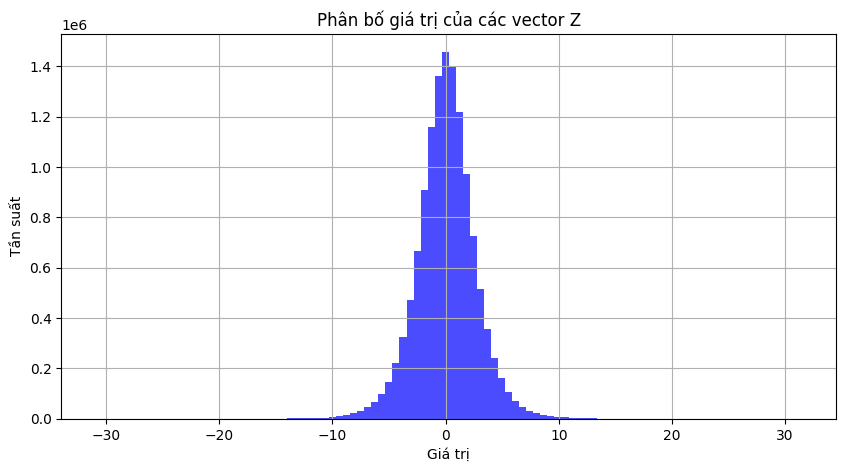

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Đường dẫn file kết quả (Sửa lại nếu cần)
Z_FILE_PATH = "/content/drive/MyDrive/BEGAN_PROJECT/inverse_results/z_dataset.npz"

def check_z_stats():
    if not os.path.exists(Z_FILE_PATH):
        print("❌ Không tìm thấy file z_dataset.npz")
        return

    print(f"📂 Đang đọc file: {Z_FILE_PATH}...")
    data = np.load(Z_FILE_PATH)
    z_vectors = data['z_vectors']
    filenames = data['filenames']

    print("-" * 30)
    print(f"✅ Tổng số vector Z đã tìm được: {len(z_vectors)}")
    print(f"✅ Kích thước mỗi vector: {z_vectors.shape[1]}")

    # Thống kê
    min_val = np.min(z_vectors)
    max_val = np.max(z_vectors)
    mean_val = np.mean(z_vectors)
    std_val = np.std(z_vectors)

    print("-" * 30)
    print("📊 THỐNG KÊ GIÁ TRỊ Z (Cực kỳ quan trọng cho Bước 4):")
    print(f"   - Min:  {min_val:.4f}")
    print(f"   - Max:  {max_val:.4f}")
    print(f"   - Mean: {mean_val:.4f} (Nên gần 0)")
    print(f"   - Std:  {std_val:.4f}")

    # Đánh giá
    print("-" * 30)
    print("KELT LUẬN SƠ BỘ:")
    if abs(min_val) > 3 or abs(max_val) > 3:
        print("⚠️ Cảnh báo: Giá trị Z có vẻ hơi lớn (vượt quá khoảng -3 đến 3).")
        print("   -> Bước 4 có thể sẽ khó hội tụ hơn một chút.")
    else:
        print("🌟 Tuyệt vời: Giá trị Z phân bố đẹp (trong khoảng -3 đến 3).")
        print("   -> Rất thuận lợi cho việc train L-Gen.")

    # Vẽ biểu đồ phân bố
    plt.figure(figsize=(10, 5))
    plt.hist(z_vectors.flatten(), bins=100, color='blue', alpha=0.7)
    plt.title("Phân bố giá trị của các vector Z")
    plt.xlabel("Giá trị")
    plt.ylabel("Tần suất")
    plt.grid(True)
    plt.show()

check_z_stats()